# Commute Data Analysis
## 1. Introduction and Data Loading

In this section, we load the dataset and perform an initial inspection.
The dataset contains commute records with details such as start/end zones, trip duration, delay status, and environmental factors.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")

# Load Data
# Fallback to Excel if CSV is missing, as seen in some versions
commute_df = pd.read_excel('/content/drive/MyDrive/26-01-04/Commute_Records.xlsx')
user_df = pd.read_excel('/content/drive/MyDrive/26-01-04/User_Profile.xlsx')

# Merge datasets if user_df is available
df = pd.merge(commute_df, user_df, on='User_id', how='left')
print("Datasets merged successfully.")

print("Data loaded successfully.")
print(f"Commute Records (Merged): {df.shape}")
print(df.head())

Datasets merged successfully.
Data loaded successfully.
Commute Records (Merged): (1500, 18)
   User_id       Date  Day_of_week  Hour_of_day  Is_peak_hour Start_zone  \
0       15 2025-11-24            5            9             1     Zone 1   
1       18 2025-11-18            5            6             0     Zone 1   
2        2 2025-11-30            5            9             1     Zone 2   
3       24 2025-11-17            4            7             1     Zone 2   
4        5 2025-11-06            3            5             0     Zone 4   

  End_zone  Distance_km  Is_rainy  Avg_trip_time_min   Line_id  \
0   Zone 1            4         0                 21   Jubilee   
1   Zone 1            8         0                 40  District   
2   Zone 1            7         1                 32   Central   
3   Zone 1            8         1                 50  Northern   
4   Zone 1           14         0                 70  Northern   

   Historical_delay_rate  Route_status Home_zone Work

In [23]:
df.shape

(1500, 18)

In [24]:
df.columns

Index(['User_id', 'Date', 'Day_of_week', 'Hour_of_day', 'Is_peak_hour',
       'Start_zone', 'End_zone', 'Distance_km', 'Is_rainy',
       'Avg_trip_time_min', 'Line_id', 'Historical_delay_rate', 'Route_status',
       'Home_zone', 'Work_zone', 'Primary_line', 'Backup_line', 'Usual_hour'],
      dtype='object')

## 2. Exploratory Data Analysis (EDA) Findings

### Feature Correlation Matrix

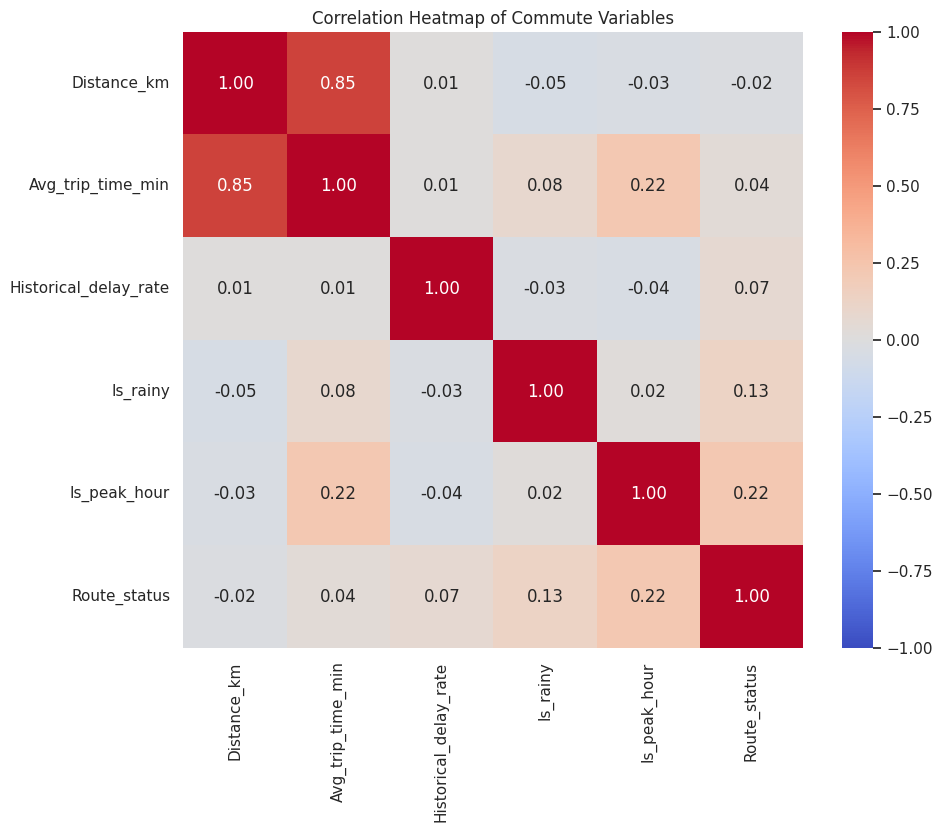

In [25]:
# 1. Select numeric columns
numeric_cols = ['Distance_km', 'Avg_trip_time_min', 'Historical_delay_rate',
                'Is_rainy', 'Is_peak_hour', 'Route_status']

# 2. Calculate Correlation Matrix
corr_matrix = df[numeric_cols].corr()

# 3. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Commute Variables')
plt.savefig('Correlation Heatmap of Commute Variables.png')
plt.show()

### Categorical Variables

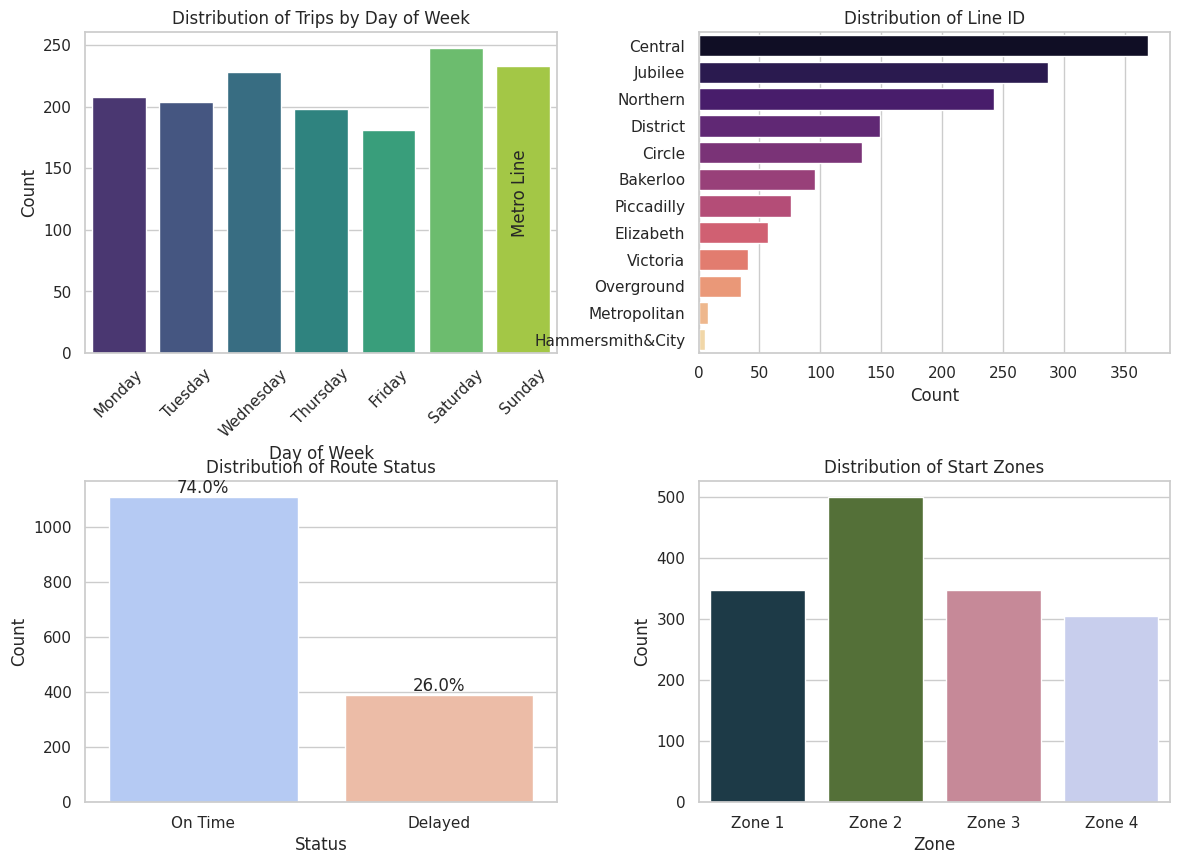

In [26]:
# 1. Data Cleaning & Preparation
# Convert Date to datetime to extract correct Day names
commute_df['Date'] = pd.to_datetime(commute_df['Date'])
commute_df['Day_Name'] = commute_df['Date'].dt.day_name()

# Map binary/numeric codes to readable labels for the plot
commute_df['Peak_Label'] = commute_df['Is_peak_hour'].map({0: 'Off-Peak', 1: 'Peak'})
commute_df['Rain_Label'] = commute_df['Is_rainy'].map({0: 'No Rain', 1: 'Rainy'})
commute_df['Status_Label'] = commute_df['Route_status'].map({0: 'On Time', 1: 'Delayed'})

# Define order for Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot A: Distribution of Trips by Day of Week
sns.countplot(data=commute_df, x='Day_Name', order=day_order, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution of Trips by Day of Week')
axes[0, 0].set_xlabel('Day of Week')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot B: Distribution of Line ID
sns.countplot(data=commute_df, y='Line_id', order=commute_df['Line_id'].value_counts().index, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Distribution of Line ID')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Metro Line')

# Plot C: Distribution of Route Status (On Time vs Delayed)
# Calculate percentages for annotation
status_counts = commute_df['Status_Label'].value_counts(normalize=True)
ax3 = sns.countplot(data=commute_df, x='Status_Label', order=['On Time', 'Delayed'], ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Distribution of Route Status')
axes[1, 0].set_xlabel('Status')
axes[1, 0].set_ylabel('Count')

# Add percentage labels to Status plot
for p in ax3.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / len(commute_df))
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax3.annotate(percentage, (x, y), ha='center', va='bottom')

# Plot D: Distribution of Start Zones
sns.countplot(data=commute_df, x='Start_zone', order=sorted(commute_df['Start_zone'].unique()), ax=axes[1, 1], palette='cubehelix')
axes[1, 1].set_title('Distribution of Start Zones')
axes[1, 1].set_xlabel('Zone')
axes[1, 1].set_ylabel('Count')
plt.savefig('Distribution of Start Zones.png')
plt.show()

### Proportion of Delayed vs. On Time Trips

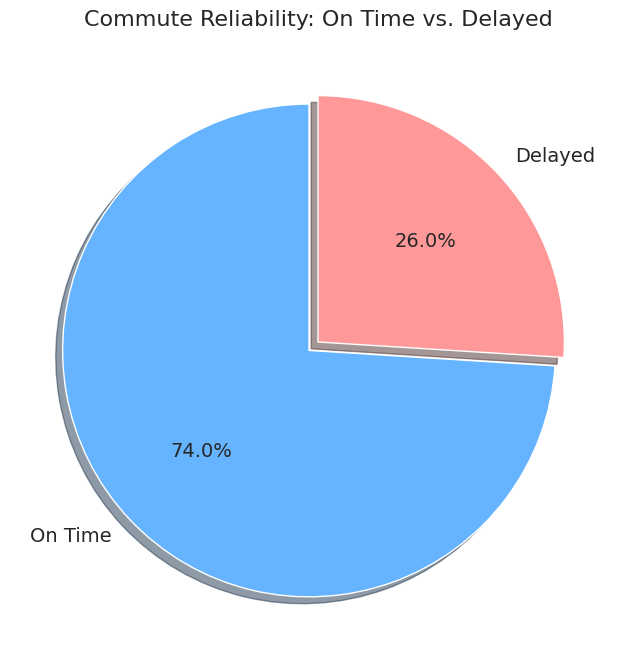

In [27]:
# 1. Prepare the data
# Map the numeric codes to text labels
df['Status_Label'] = df['Route_status'].map({0: 'On Time', 1: 'Delayed'})
counts = df['Status_Label'].value_counts()

# 2. Create the Pie Chart
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999'] # Blue for good, Red for bad
explode = (0.05, 0)  # slightly separate the main slice

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode, shadow=True, textprops={'fontsize': 14})

plt.title('Commute Reliability: On Time vs. Delayed', fontsize=16)
plt.savefig('Commute Reliability: On Time vs. Delayed.png')
plt.show()

### Analysis of Variables Distribution and Impact

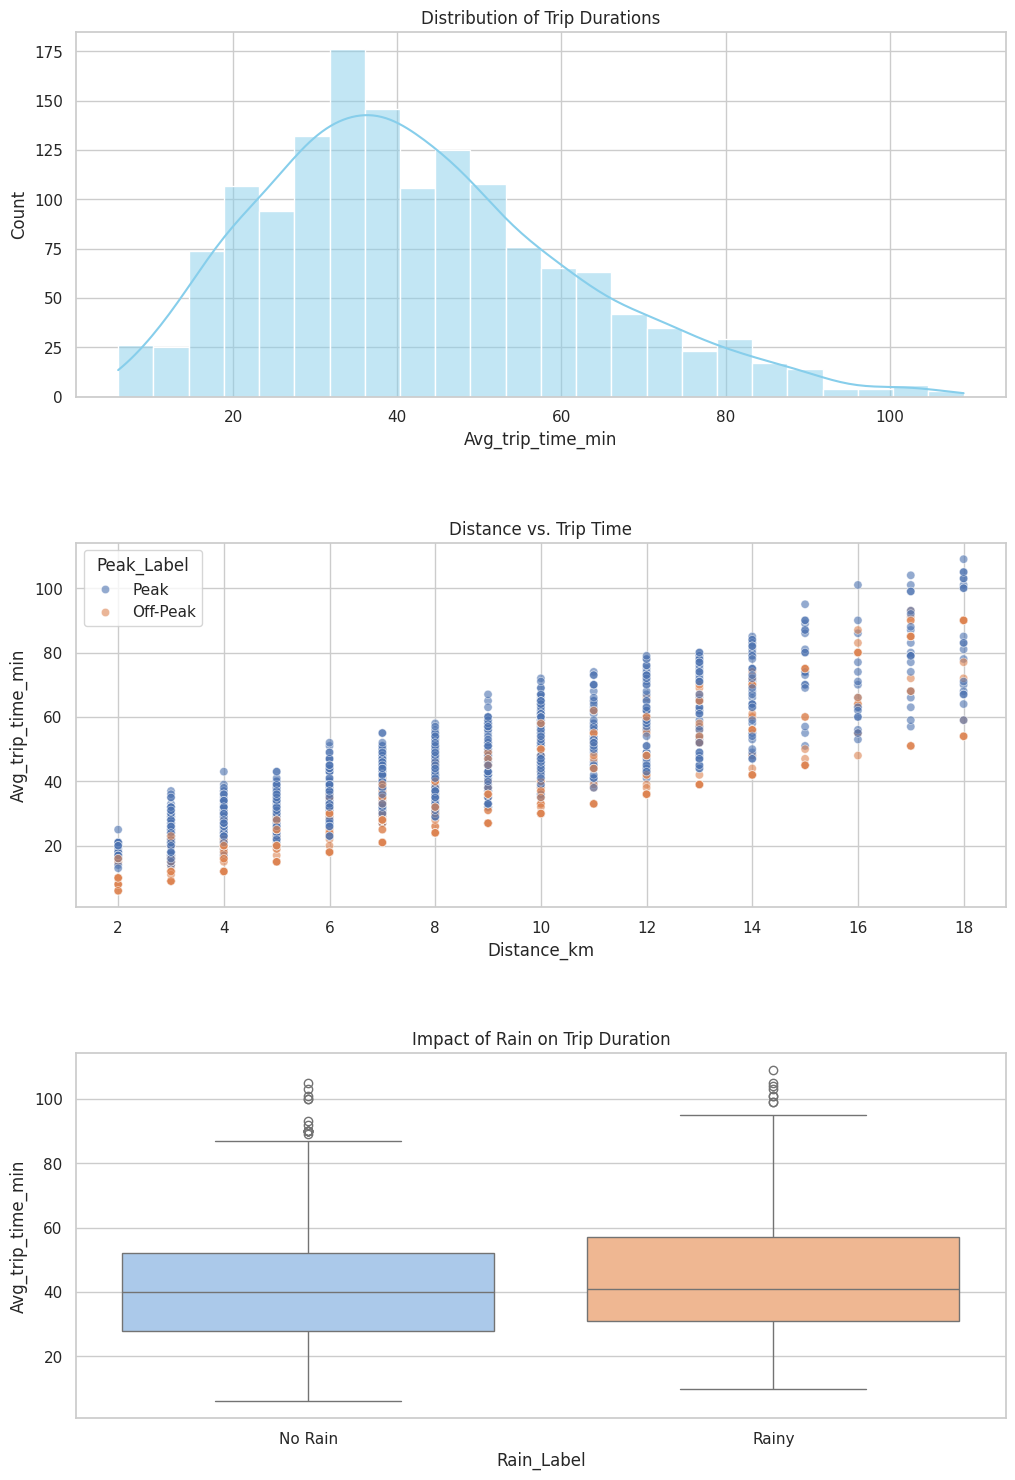

In [28]:
# 1. Setup Labels
df['Rain_Label'] = df['Is_rainy'].map({0: 'No Rain', 1: 'Rainy'})
df['Peak_Label'] = df['Is_peak_hour'].map({0: 'Off-Peak', 1: 'Peak'})

# 2. Create Plots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot A: Trip Duration Histogram
sns.histplot(data=df, x='Avg_trip_time_min', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Trip Durations')

# Plot B: Distance vs Time Scatter
sns.scatterplot(data=df, x='Distance_km', y='Avg_trip_time_min', hue='Peak_Label', alpha=0.6, ax=axes[1], palette='deep')
axes[1].set_title('Distance vs. Trip Time')

# Plot C: Rain Impact Boxplot
sns.boxplot(data=df, x='Rain_Label', y='Avg_trip_time_min', ax=axes[2], palette='pastel')
axes[2].set_title('Impact of Rain on Trip Duration')
plt.savefig('Analysis of Variables Distribution and Impact.png')
plt.show()

### Detailed Trip Time Analysis (Combined)

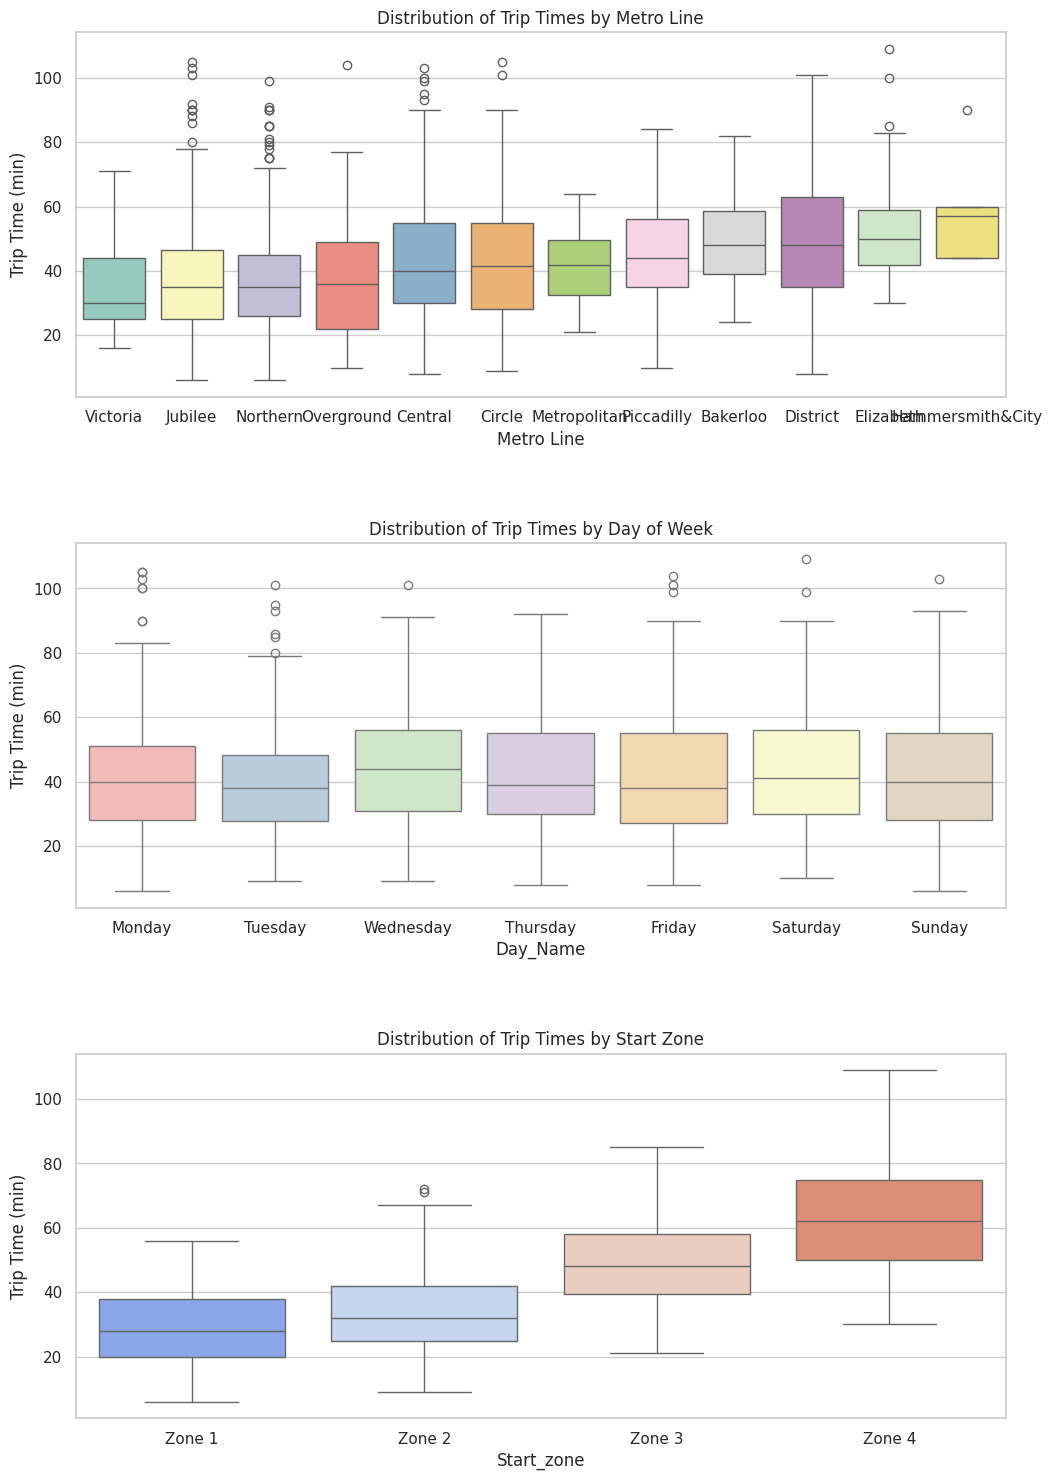

In [29]:
# 1. Prepare Data for Boxplots
if 'Date' not in df.columns or not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'])
df['Day_Name'] = df['Date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
zone_order = sorted(df['Start_zone'].unique())

# 2. Create Combined Plots (3 Subplots)
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

# Plot A: Trip Time by Line (Sorted by median time)
line_order = df.groupby('Line_id')['Avg_trip_time_min'].median().sort_values().index
sns.boxplot(data=df, x='Line_id', y='Avg_trip_time_min', order=line_order, ax=axes[0], palette='Set3')
axes[0].set_title('Distribution of Trip Times by Metro Line')
axes[0].set_xlabel('Metro Line')
axes[0].set_ylabel('Trip Time (min)')

# Plot B: Trip Time by Day
sns.boxplot(data=df, x='Day_Name', y='Avg_trip_time_min', order=day_order, ax=axes[1], palette='Pastel1')
axes[1].set_title('Distribution of Trip Times by Day of Week')
axes[1].set_ylabel('Trip Time (min)')

# Plot C: Trip Time by Zone
sns.boxplot(data=df, x='Start_zone', y='Avg_trip_time_min', order=zone_order, ax=axes[2], palette='coolwarm')
axes[2].set_title('Distribution of Trip Times by Start Zone')
axes[2].set_ylabel('Trip Time (min)')
plt.savefig('Distribution of Trip Times by Start Zone.png')
plt.show()

### Exit Zone and Flow Analysis

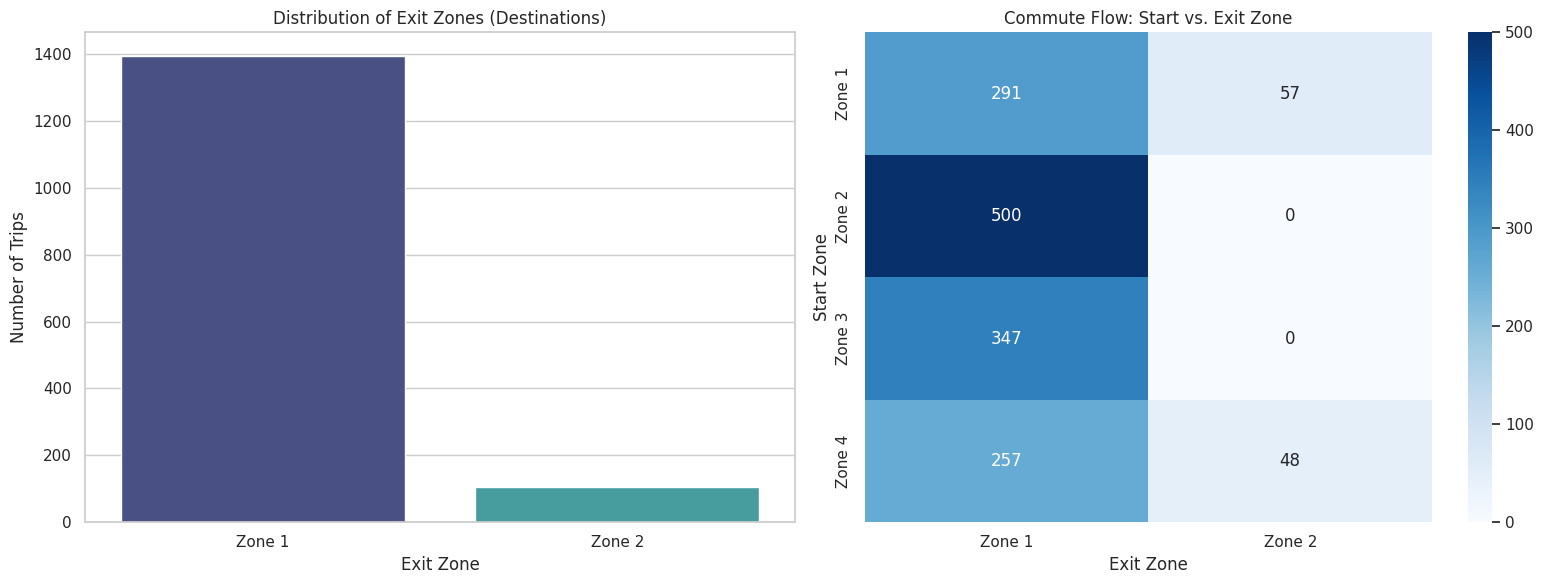

In [30]:
# 1. Setup the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Distribution of Exit Zones (End_zone)
# We calculate the counts for each destination zone
exit_counts = df['End_zone'].value_counts()
sns.barplot(x=exit_counts.index, y=exit_counts.values, ax=axes[0], palette='mako')
axes[0].set_title('Distribution of Exit Zones (Destinations)')
axes[0].set_xlabel('Exit Zone')
axes[0].set_ylabel('Number of Trips')

# Plot B: Entry vs Exit Heatmap (Flow)
# We create a crosstab to see the flow from Start to End
flow_matrix = pd.crosstab(df['Start_zone'], df['End_zone'])
sns.heatmap(flow_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Commute Flow: Start vs. Exit Zone')
axes[1].set_xlabel('Exit Zone')
axes[1].set_ylabel('Start Zone')

plt.tight_layout()
plt.savefig('Exit Zone and Flow Analysis.png')
plt.show()

# 3. Feature Engineering and Model Implementation
## Feature Engineering

In [33]:
df_copy = df.copy()

In [34]:
# df.columns

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from imblearn.over_sampling import SMOTE


# Ensure Date processing is done for Feature Engineering
# 1. Feature Construction (Advanced Feature Engineering)
# Create interaction features between Trip data and User Profile if available
if 'Primary_line' in df.columns:
    print("Generating interaction features from User Profile...")
    # Line matching
    df['Is_Primary_Line'] = (df['Line_id'] == df['Primary_line']).astype(int)
    df['Is_Backup_Line'] = (df['Line_id'] == df['Backup_line']).astype(int)

    # Zone matching
    df['Is_Home_Start'] = (df['Start_zone'] == df['Home_zone']).astype(int)
    df['Is_Work_End'] = (df['End_zone'] == df['Work_zone']).astype(int)

    # Time deviation
    if 'Usual_hour' in df.columns:
        df['Hour_Diff'] = abs(df['Hour_of_day'] - df['Usual_hour'])

# 2. Feature Selection
# Drop Date, ID columns, and Target
# Also drop 'Avg_trip_time_min' to avoid leakage (as discussed)
drop_cols = ['Date', 'Avg_trip_time_min', 'User_id']
X = df.drop(columns=['Route_status'] + drop_cols, errors='ignore')
y = df['Route_status']

# Define features groups
categorical_features = ['Line_id', 'Start_zone', 'End_zone', 'Day_Name']
numerical_features = ['Distance_km', 'Historical_delay_rate', 'Is_rainy', 'Is_peak_hour']

# Add constructed features to numerical (boolean 0/1 are treated as numerical/binary safe for scaling or pass-through)
constructed_features = ['Is_Primary_Line', 'Is_Backup_Line', 'Is_Home_Start', 'Is_Work_End', 'Hour_Diff']
numerical_features += [c for c in constructed_features if c in X.columns]

# Also include original profile features if needed, but interactions are often better.
# Let's include 'Usual_hour' as numeric if not present
if 'Usual_hour' in X.columns and 'Usual_hour' not in numerical_features:
    numerical_features.append('Usual_hour')

# Note: We avoid adding high-cardinality profile features like 'Home_zone' directly
# if we already have 'Is_Home_Start', but XGBoost might handle them well.
# Let's add them to categorical just in case, but keep the list clean.
extra_cats = ['Home_zone', 'Work_zone', 'Primary_line', 'Backup_line']
categorical_features += [c for c in extra_cats if c in X.columns]

print(f"Selected Categorical Features: {len(categorical_features)} columns")
print(f"Selected Numerical Features: {len(numerical_features)} columns")

# 3. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)
    ],sparse_threshold=0)

# Apply transformations
# Fill NaNs before processing if any (from left join)
X = X.fillna(0) # Simple imputation for binary/numeric features constructed above

X_processed = preprocessor.fit_transform(X)

# Get feature names
ohe = preprocessor.named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_cols)
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

# 4. Final Data Prep
X_resampled, y_resampled = SMOTE(random_state=0).fit_resample(X_processed_df, y)

Generating interaction features from User Profile...
Selected Categorical Features: 8 columns
Selected Numerical Features: 10 columns


## Model Implementation

We implement four supervised learning models to predict delay:
1. Decision Tree
2. Random Forest
3. Logistic Regression
4. XGBoost

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Split Data (70% Train, 15% Validation, 15% Test)
# First split: 85% Train+Val, 15% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(X_resampled, y_resampled, test_size=0.15, random_state=42)
# Second split: 70/85 (approx 0.82) of Train+Val -> Train, rest Validation
# Effectively 70% original total for Train, 15% Val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42)


# 1. Hyperparameter Tuning for XGBoost
print("Tuning XGBoost...")
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                        xgb_param_grid, cv=3, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGB Params: {xgb_grid.best_params_}")

# 2. Hyperparameter Tuning for Random Forest
print("Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_param_grid, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")

# Initialize Models (Data balanced via SMOTE)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": best_rf,
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": best_xgb
}

# Dictionary to store results
results = {}

print("Training Models...")
for name, model in models.items():
    # Train
    if name not in ["Random Forest", "XGBoost"]: # Already trained during tuning
        model.fit(X_train, y_train)

    # Predict on Test Set (using Test set for final reporting as per report structure, though validation is usually for tuning)
    # Here we use the Test set for the metrics table
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan')

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC-ROC": auc
    }
    print(f"{name} trained.")

Tuning XGBoost...
Best XGB Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Tuning Random Forest...
Best RF Params: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Training Models...
Decision Tree trained.
Random Forest trained.
Logistic Regression trained.
XGBoost trained.


# 4. Model Evaluation and Performance
## Performance Metrics

                     Accuracy  Precision    Recall  F1 Score   AUC-ROC
Decision Tree        0.708709   0.729885  0.717514  0.723647  0.708116
Random Forest        0.774775   0.800000  0.768362  0.783862  0.875960
Logistic Regression  0.636637   0.648936  0.689266  0.668493  0.710633
XGBoost              0.759760   0.805031  0.723164  0.761905  0.856113


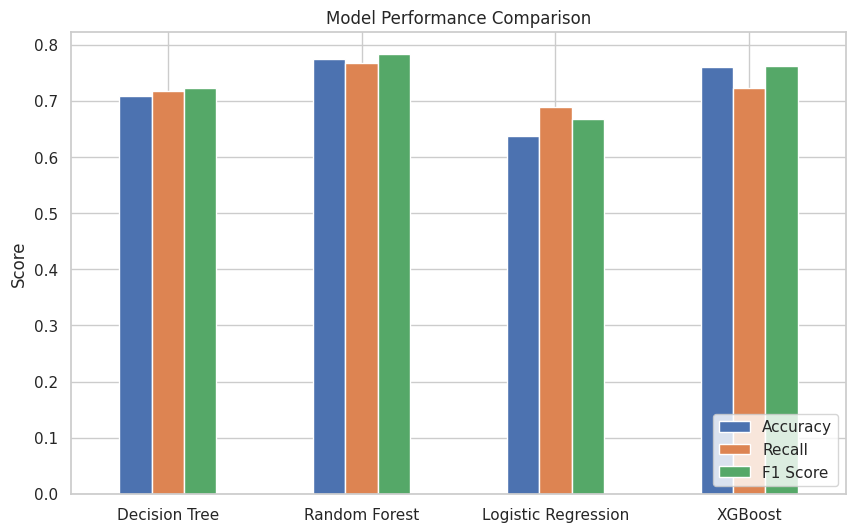

In [39]:
# Create DataFrame from results
results_df = pd.DataFrame(results).T
print(results_df)

# Visualization of Metrics
results_df[['Accuracy', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.savefig('Model Performance Comparison.png')
plt.show()

## Evaluation
Based on the metrics above, we can observe which model performs best for predicting commute delays.
Usually, **Recall** is critical if we want to ensure we catch all potential delays (minimizing false negatives),
while **Precision** is important if we want to avoid false alarms.
**XGBoost** and **Random Forest** typically perform well on tabular data with categorical features.

### Feature Importance (XGBoost)

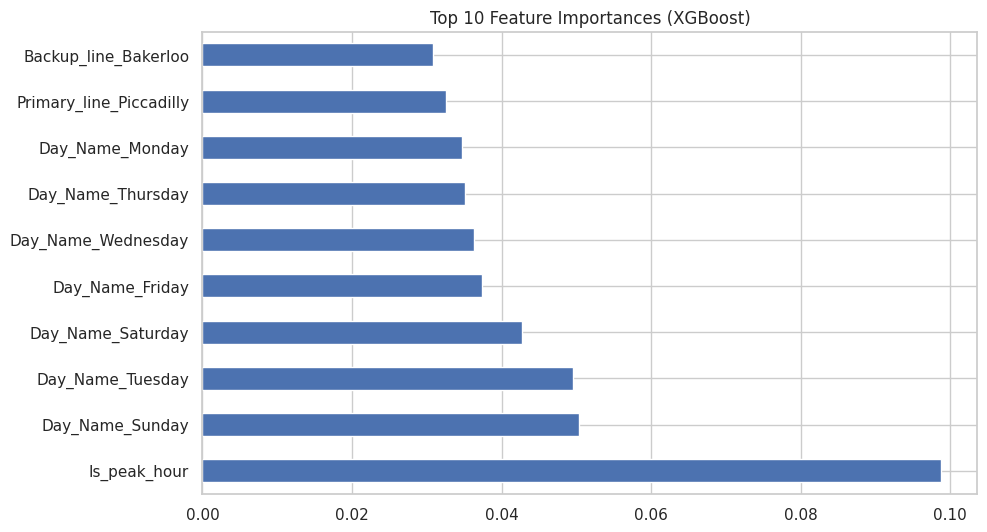

In [40]:
if 'XGBoost' in models:
    importances = best_xgb.feature_importances_
    feature_names = all_feature_names
    feat_importances = pd.Series(importances, index=feature_names)
    feat_importances.nlargest(10).plot(kind='barh', figsize=(10, 6))
    plt.title('Top 10 Feature Importances (XGBoost)')
    plt.savefig('Top 10 Feature Importances (XGBoost).png')
    plt.show()